## **<font color="crimson"> Ya ok </font>**

In [54]:
pip install cartopy

Note: you may need to restart the kernel to use updated packages.


In [55]:
pip install h5netcdf 

Note: you may need to restart the kernel to use updated packages.


In [56]:
pip install xarray

Note: you may need to restart the kernel to use updated packages.


In [57]:
pip install cftime

Note: you may need to restart the kernel to use updated packages.


In [58]:
pip install toolz

Note: you may need to restart the kernel to use updated packages.


In [1]:
import xarray as xr
import numpy as np
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import matplotlib.patches as patches
import cftime

### **<font color="Purple"> Datos de ERA-5 </font>**

### **<font color="olive"> Temperatura</font>**

In [2]:
filet2m_era5 = 'datasetsok/t2mC_1979-2024large.nc'

In [3]:
t2m_ds=xr.open_dataset(filet2m_era5)
t2m=t2m_ds['t2m']

In [4]:
t2m_inviernos = t2m.sel(time=t2m['time.month'].isin([12, 1, 2]))

##### Climatología diaria

In [5]:
file_anomt2m = 'datasetsok/anomalias_day_t2mE5.nc'
anom_t2m = xr.open_dataset(file_anomt2m)
anomaliasday_t2m = anom_t2m['t2m']

### **<font color="olive"> Viento </font>**

In [6]:
fileu_era5 = 'datasetsok/u_daily_500_200_1979-2024.nc'

In [7]:
u_ds = xr.open_dataset(fileu_era5)
u_era5 = u_ds['u']

In [8]:
#Seleccionar solo 200 hPa 
u200E5 = u_era5.sel(pressure_level=200)

In [9]:
u_inviernosE5 = u200E5.sel(time=u200E5['time.month'].isin([12, 1, 2]))

##### Climatología diaria

In [10]:
file_anomu = 'datasetsok/anomalias_day_uE5.nc'
anom_u = xr.open_dataset(file_anomu)
anomaliasday_u = anom_u['u']
anomdayu= anomaliasday_u.sel(time=anomaliasday_u['time.month'].isin([12, 1, 2]))

### **<font color="olive"> CAOs de ERA5</font>**

In [11]:
# A invierno le vamos a poner las fechas del df 

In [12]:
caosE5df = pd.read_csv('datasetsok/fechasCAO_E5.csv')

In [38]:
caosE5df

,fecha,indice
0,1986-01-09,640
1,1979-01-02,1
2,1979-01-03,2
3,1986-01-10,641
4,2002-01-02,2077
...,...,...
65,2007-01-25,2551
66,2010-01-09,2806
67,2022-12-24,3963
68,2022-12-25,3964


In [13]:
indicescaoE5 = caosE5df['indice']
fechascaoE5 = caosE5df['fecha']
# fechascaoE5

### **<font color="olive"> CAOs de ERA5 hasta 2014</font>**

In [14]:
caosE5dfROSARIO = pd.read_csv('datasetsok/ROSARIOfechasCAO_E5.csv')
indicescaoE5ROSARIO = caosE5dfROSARIO['indice']
fechascaoE5ROSARIO = caosE5dfROSARIO['fecha']

##### **<font color="olive"> Temperatura durante CAO </font>**

In [15]:
t_caosE5 = t2m_inviernos.isel(time=indicescaoE5) #así funciona pero necesito comprobar que los indices estan bien

In [16]:
TmeanCAO_E5 = t_caosE5.mean('time')

In [17]:
TanomaliaE5 = TmeanCAO_E5 - t2m_inviernos

##### **<font color="olive"> Temperatura durante CAO hasta 2014</font>**

In [18]:
t_caosE5ROSARIO = t2m_inviernos.isel(time=indicescaoE5ROSARIO) #así funciona pero necesito comprobar que los indices estan bien

In [19]:
TmeanCAO_E5ROSARIO = t_caosE5ROSARIO.mean('time')

In [20]:
TanomaliaE5ROSARIO = TmeanCAO_E5ROSARIO - t2m_inviernos

##### **<font color="olive"> Viento durante CAO </font>**

In [21]:
u_caosE5 = u_inviernosE5.isel(time=indicescaoE5) 

In [22]:
VmeanCAO_E5 = u_caosE5.mean('time')

In [23]:
VanomaliaE5  = VmeanCAO_E5 - u_inviernosE5 #CHECAR QUE ESTE BIEN este es un método

##### **<font color="olive"> Viento durante CAO hasta 2014</font>**

In [24]:
u_caosE5ROSARIO = u_inviernosE5.isel(time=indicescaoE5ROSARIO) 

In [25]:
VmeanCAO_E5ROSARIO = u_caosE5ROSARIO.mean('time')

In [26]:
VanomaliaE5ROSARIO  = VmeanCAO_E5ROSARIO - u_inviernosE5 #CHECAR QUE ESTE BIEN este es un método

DETREND

In [27]:
def detrend_dataarray_preserve_mean(da, dim='time'):
    """
    Remove the linear trend (slope) along the specified dimension from an xarray DataArray,
    while preserving the original mean of the data.

    Parameters:
      da (xr.DataArray): The input data array.
      dim (str): The dimension along which to detrend (default is 'time').

    Returns:
      xr.DataArray: The detrended data array with the original mean preserved.
    """
    # Convert time coordinate to numeric values.
    if isinstance(da[dim].values[0], cftime.datetime):
        try:
            calendar = da[dim].values[0].calendar
        except AttributeError:
            calendar = 'standard'
        units = "days since 2000-01-01"
        time_numeric_values = [cftime.date2num(t, units, calendar) for t in da[dim].values]
        time_numeric = xr.DataArray(time_numeric_values, dims=dim, coords={dim: da[dim]})
    else:
        time_numeric = xr.DataArray(
            da[dim].values.astype('float64'),
            dims=dim,
            coords={dim: da[dim]}
        )
    
    def detrend_1d_preserve_mean(y, x):
        # Fit a linear trend
        p = np.polyfit(x, y, 1)
        slope, intercept = p
        # Subtract only the slope * (x - mean(x)) to preserve the overall mean.
        return y - slope * (x - np.mean(x))
    
    detrended = xr.apply_ufunc(
        detrend_1d_preserve_mean,
        da,
        time_numeric,
        input_core_dims=[[dim], [dim]],
        output_core_dims=[[dim]],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[da.dtype]
    )
    
    return detrended

# Example usage:
# da_detrended = detrend_dataarray_preserve_mean(regionHG, dim='time')


In [28]:
anomday_detrendE5 = detrend_dataarray_preserve_mean(anomaliasday_t2m, dim='time') #aquí les está quitando la tendencia de CC a las anomalías
anomday_detrend_t2mDJF=anomday_detrendE5.sel(time=anomday_detrendE5['time.month'].isin([12, 1, 2]))

##### **<font color="olive"> MÉTODO 1. Ciclo anual temperatura </font>**

In [29]:
# hasta 2014 --------------
tempsE5dayROSARIO = anomday_detrend_t2mDJF.isel(time=indicescaoE5ROSARIO)
tempsE5dayROSARIO = tempsE5dayROSARIO.mean(dim='time')
# fechascaoE5

# fechascaoE5
# ERA ---------------------
tempsE5day = anomday_detrend_t2mDJF.isel(time=indicescaoE5)
tempsE5day = tempsE5day.mean(dim='time')
# fechascaoE5

##### **<font color="olive"> MÉTODO 2. Estacionalidad temperatura </font>**

In [30]:
# # hasta 2014--------------
# TmeanCAO_E5ROSARIO
# TanomaliaE5ROSARIO = TanomaliaE5.mean(dim='time')


# # ERA ---------------------
# TmeanCAO_E5
# TanomaliaE5 = TanomaliaE5.mean(dim='time')

##### **<font color="olive"> MÉTODO 1. Ciclo anual viento </font>**

In [31]:
# hasta 2014--------------
usE5dayROSARIO = anomdayu.isel(time=indicescaoE5ROSARIO) 
usE5dayROSARIO = usE5dayROSARIO.mean(dim='time')
# ERA ---------------------
usE5day = anomdayu.isel(time=indicescaoE5) 
usE5day = usE5day.mean(dim='time')
# usE5day
# fechascaoE5

##### **<font color="olive"> MÉTODO 2. Estacionalidad viento </font>**

In [32]:
# # HADGEM --------------
# VmeanCAO_HG
# VanomaliaHG =  VanomaliaHG.mean(dim='time')  

# # ERA ---------------------
# VmeanCAO_E5
# VanomaliaE5 = VanomaliaE5.mean(dim='time') 

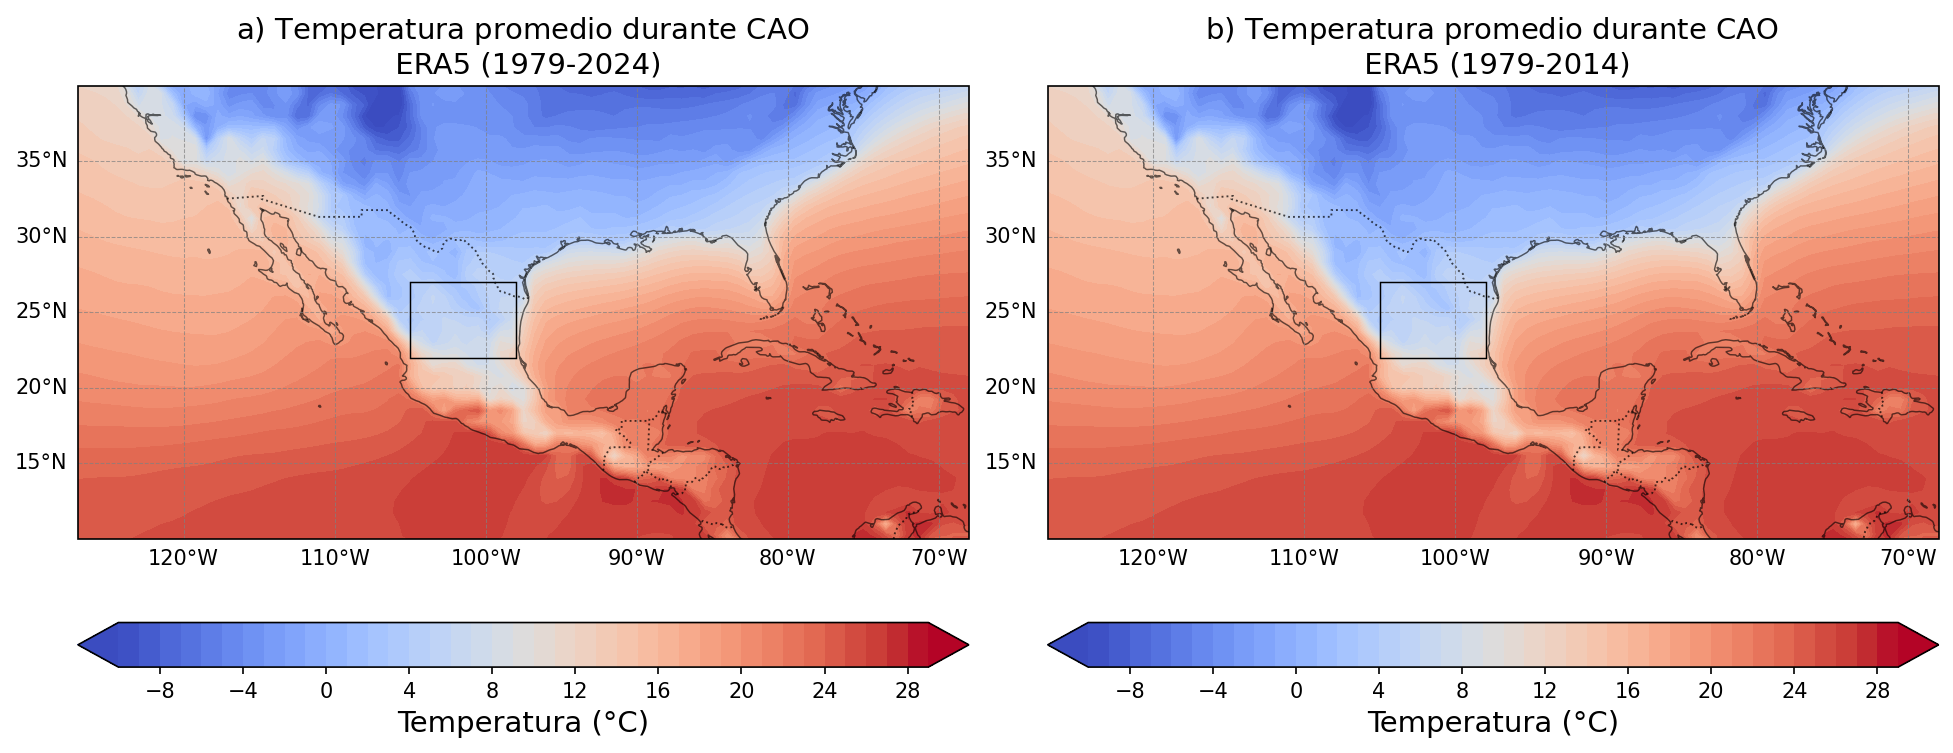

In [33]:
# Usar constrained_layout en lugar de tight_layout
fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})

# Subplot 1 - HadGEM3
ax1 = axes[1]
ax1.coastlines(linewidth=0.7,alpha=0.6)
cs1 = ax1.contourf(TmeanCAO_E5.longitude, TmeanCAO_E5.latitude, TmeanCAO_E5, levels=np.arange(-10, 30, 1), cmap='coolwarm', extend='both', transform=ccrs.PlateCarree())
ax1.add_feature(cfeature.BORDERS, linestyle=':',linewidth=0.9,alpha=0.7)
ax1.set_extent([233, 292, 10, 40], crs=ccrs.PlateCarree())
rect = patches.Rectangle((255, 22), 262-255, 27-22, 
                         linewidth=0.7, edgecolor='black', facecolor='none', 
                         transform=ccrs.PlateCarree(), zorder=10)
ax1.add_patch(rect)
gl1 = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
gl1.top_labels = gl1.right_labels = False
ax1.tick_params(labelsize=12)
ax1.set_title('b$)$ Temperatura promedio durante CAO \n ERA5 (1979-2014)', fontsize=14)

# Subplot 2 - ERA5
ax2 = axes[0]
ax2.coastlines(linewidth=0.7,alpha=0.6)
cs2 = ax2.contourf(TmeanCAO_E5.longitude, TmeanCAO_E5.latitude, TmeanCAO_E5, levels=np.arange(-10, 30, 1), cmap='coolwarm', extend='both', transform=ccrs.PlateCarree())
ax2.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.9,alpha=0.7)
ax2.set_extent([233, 292, 10, 40], crs=ccrs.PlateCarree())
rect = patches.Rectangle((255, 22), 262-255, 27-22, 
                         linewidth=0.7, edgecolor='black', facecolor='none', 
                         transform=ccrs.PlateCarree(), zorder=10)
ax2.add_patch(rect)
gl2 = ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
gl2.top_labels = gl2.right_labels = False
ax2.tick_params(labelsize=12) 
ax2.set_title('a$)$ Temperatura promedio durante CAO \n ERA5 (1979-2024)', fontsize=14)

# Colorbar único
cbar = fig.colorbar(cs2, ax=ax1, orientation='horizontal', fraction=0.09, pad=0.1)
cbar.ax.set_xlabel('Temperatura (°C)', fontsize=14)
cbar = fig.colorbar(cs1, ax=ax2, orientation='horizontal', fraction=0.09, pad=0.1)
cbar.ax.set_xlabel('Temperatura (°C)', fontsize=14)
fig.tight_layout(pad=0.5,w_pad=0.5)
plt.savefig("figsok/ROSARIOTmeanCAO.png", bbox_inches='tight')

plt.show()


In [34]:
# fig, axs = plt.subplots(2, 2, figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
# plt.subplots_adjust(wspace=0.2, hspace=0.35)
# axs = axs.flatten()

# # MÉTODO 1: SIN CICLO ANUAL HG ( YA OK ) -------------------------------------------------------------------------------------------
# ax = axs[0]
# ax.coastlines(linewidth=0.7,alpha=0.6)
# cs = ax.contourf(TmeanCAO_HG.lon, TmeanCAO_HG.lat, TmeanCAO_HG, levels=np.arange(-10, 30, 1), cmap='coolwarm', extend='both', transform=ccrs.PlateCarree())
# ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.9,alpha=0.7)
# ax.set_extent([231, 293, 10, 40], crs=ccrs.PlateCarree())
# rect = patches.Rectangle((255, 22), 262-255, 27-22, 
#                          linewidth=0.7, edgecolor='black', facecolor='none', 
#                          transform=ccrs.PlateCarree(), zorder=10)
# ax.add_patch(rect)
# gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
# gl.top_labels = gl.right_labels = False
# plt.minorticks_on()
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.1, ax=ax, pad=0.1)
# cbar.ax.set_xlabel('Temperatura superficial [°C]', fontsize=10)
# ax.set_title('a$)$ HadGEM3 cuadrante norte', fontsize=12)

# # MÉTODO 1: SIN CICLO ANUAL E5 ( YA OK ) -------------------------------------------------------------------------------------------
# ax = axs[1]
# ax.coastlines(linewidth=0.7,alpha=0.6)
# cs = ax.contourf(TmeanCAO_E5.longitude, TmeanCAO_E5.latitude, TmeanCAO_E5, levels=np.arange(-10, 30, 1), cmap='coolwarm', extend='both', transform=ccrs.PlateCarree())
# ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.9,alpha=0.7)
# ax.set_extent([231, 293, 10, 40], crs=ccrs.PlateCarree())
# rect2 = patches.Rectangle((255, 22), 262-255, 27-22, 
#                          linewidth=0.7, edgecolor='black', facecolor='none', 
#                          transform=ccrs.PlateCarree(), zorder=10)
# ax.add_patch(rect2)
# gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
# gl.top_labels = gl.right_labels = False
# plt.minorticks_on()
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.1, ax=ax, pad=0.1)
# cbar.ax.set_xlabel('Temperatura superficial [°C]', fontsize=10)
# ax.set_title('b$)$ ERA5 cuadrante norte', fontsize=12)

# # MÉTODO 2: CICLO ANUAL HG  -------------------------------------------------------------------------------------------
# ax = axs[2]
# ax.coastlines(linewidth=0.7,alpha=0.6)
# cs = ax.contourf(tempsHGday.lon, tempsHGday.lat, tempsHGday, levels=np.arange(-10,30,1), cmap='coolwarm', extend='both', transform=ccrs.PlateCarree())
# ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.9,alpha=0.7)
# ax.set_extent([231, 293, 10, 40], crs=ccrs.PlateCarree())
# rect3 = patches.Rectangle((255, 17), 262-255, 22-17, 
#                          linewidth=0.7, edgecolor='black', facecolor='none', 
#                          transform=ccrs.PlateCarree(), zorder=10)
# ax.add_patch(rect3)
# gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
# gl.top_labels = gl.right_labels = False
# plt.minorticks_on()
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.1, ax=ax, pad=0.1)
# cbar.ax.set_xlabel('Temperatura superficial [°C]', fontsize=10)
# ax.set_title('c$)$ HadGEM3 cuadrante sur', fontsize=12)

# # MÉTODO 2: CICLO ANUAL E5 -------------------------------------------------------------------------------------------
# ax = axs[3]
# ax.coastlines(linewidth=0.7,alpha=0.6)
# cs = ax.contourf(tempsE5day.longitude, tempsE5day.latitude, tempsE5day, levels=np.arange(-10,30,1), cmap='coolwarm', extend='both', transform=ccrs.PlateCarree())
# ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.9,alpha=0.7)
# ax.set_extent([231, 293, 10, 40], crs=ccrs.PlateCarree())
# rect4 = patches.Rectangle((255, 17), 262-255, 22-17, 
#                          linewidth=0.7, edgecolor='black', facecolor='none', 
#                          transform=ccrs.PlateCarree(), zorder=10)
# ax.add_patch(rect4)

# gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
# gl.top_labels = gl.right_labels = False
# plt.minorticks_on()
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.1, ax=ax, pad=0.1)
# cbar.ax.set_xlabel('Temperatura superficial [°C]', fontsize=10)
# ax.set_title('d$)$ ERA5 cuadrante sur', fontsize=12)

# plt.tight_layout()
# plt.subplots_adjust(top=.95)
# # plt.suptitle('Temperatura durante eventos CAO en dos cuadrantes',fontsize=14,color="k",fontstyle='italic',fontweight='bold');


# plt.savefig('figs/6_TmeanCAO_NyS')

----
## **<font color="crimson"> Ya ok </font>**

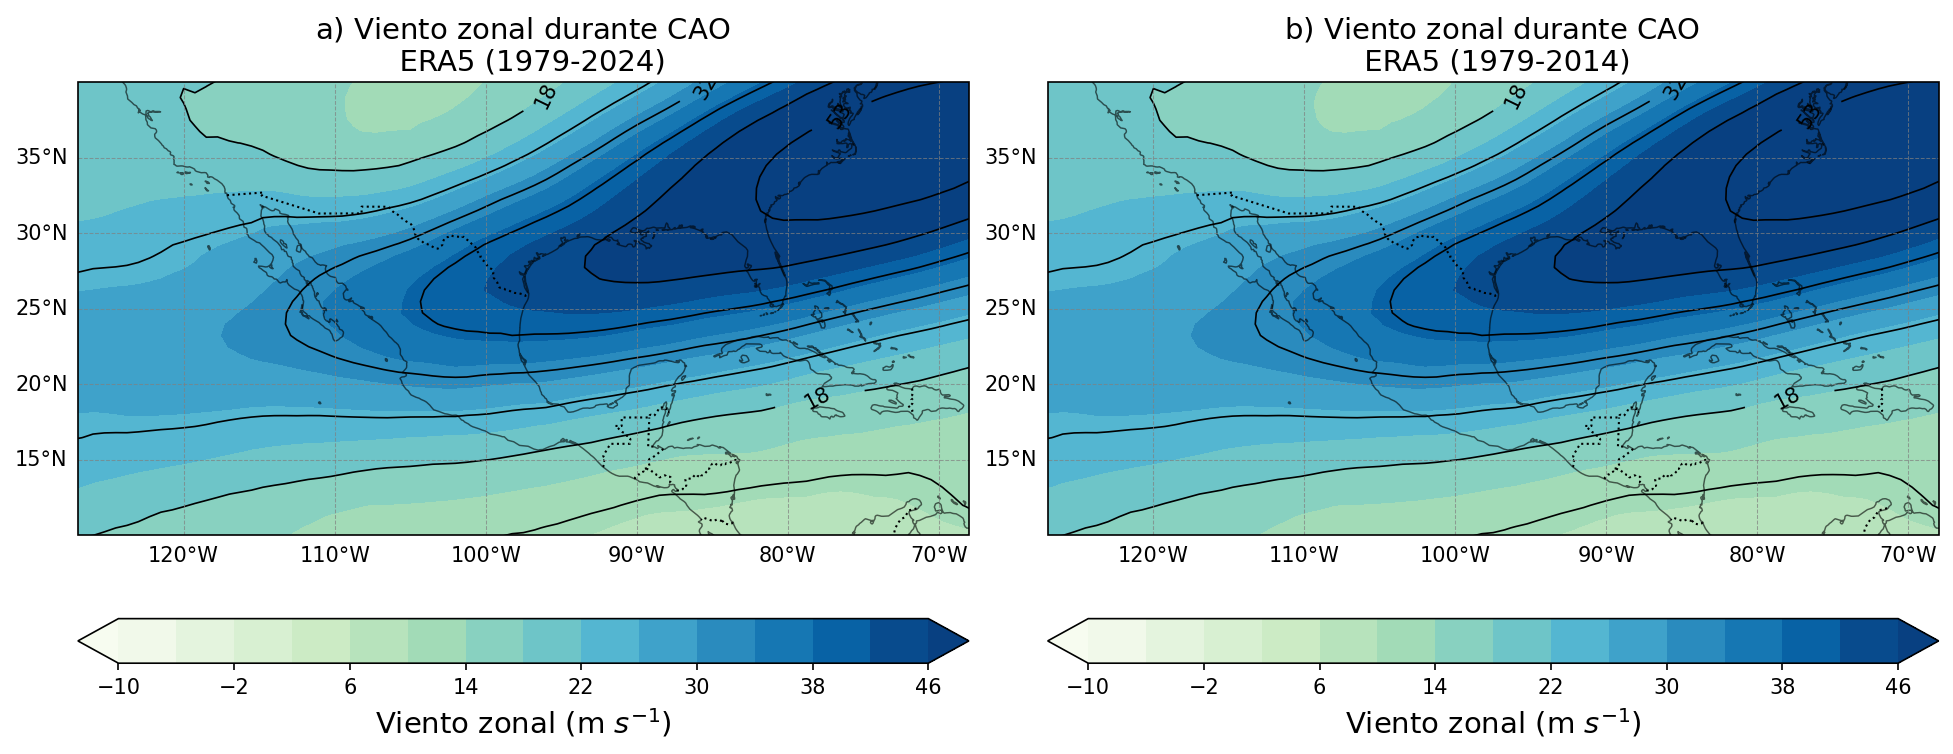

In [35]:
# Crear figura
fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})

# Subplot 1
# ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1 = axes[1]
ax1.coastlines(linewidth=0.7, alpha=0.6)
cs = ax1.contourf(VmeanCAO_E5ROSARIO.longitude, VmeanCAO_E5ROSARIO.latitude,VmeanCAO_E5, levels=np.arange(-10, 50, 4), cmap='GnBu', extend='both', transform=ccrs.PlateCarree())
cc = ax1.contour(VmeanCAO_E5.longitude, VmeanCAO_E5.latitude,VmeanCAO_E5, levels=np.arange(-10, 60, 7), colors='k', linewidths=0.8, transform=ccrs.PlateCarree())
ax1.clabel(cc, cc.levels, inline=True, fontsize=10)
ax1.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1)
ax1.set_extent([233, 292, 10, 40], crs=ccrs.PlateCarree())
gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
gl.top_labels = gl.right_labels = False
cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.09, pad=0.1, ax=ax1)
cbar.ax.set_xlabel('Viento zonal (m $s^{-1}$)', fontsize=14)
ax1.set_title('b$)$ Viento zonal durante CAO \n ERA5 (1979-2014)', fontsize=14)

# Subplot 2
ax2 = axes[0]
ax2.coastlines(linewidth=0.7, alpha=0.6)
cs = ax2.contourf(VmeanCAO_E5.longitude, VmeanCAO_E5.latitude, VmeanCAO_E5, levels=np.arange(-10, 50, 4), cmap='GnBu', extend='both', transform=ccrs.PlateCarree())
cc = ax2.contour(VmeanCAO_E5.longitude, VmeanCAO_E5.latitude, VmeanCAO_E5, levels=np.arange(-10, 60, 7), colors='k', linewidths=0.8, transform=ccrs.PlateCarree())
ax2.clabel(cc, cc.levels, inline=True, fontsize=10)
ax2.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1)
ax2.set_extent([233, 292, 10, 40], crs=ccrs.PlateCarree())
gl = ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
gl.top_labels = gl.right_labels = False
cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.09,pad=0.1, ax=ax2)
cbar.ax.set_xlabel('Viento zonal (m $s^{-1}$)', fontsize=14)
ax2.set_title('a$)$ Viento zonal durante CAO \n  ERA5 (1979-2024)', fontsize=14)

fig.tight_layout(pad=0.5,w_pad=0.5)

plt.savefig("figsok/ROSARIO8_VmeanCAO.png", bbox_inches='tight')


----
## **<font color="crimson"> Ya ok </font>**

###### <h1  style="color:purple; font-size:20px;"><i> Climatología de temperatra superficial en CAOS con dos métodos </i> </h1>

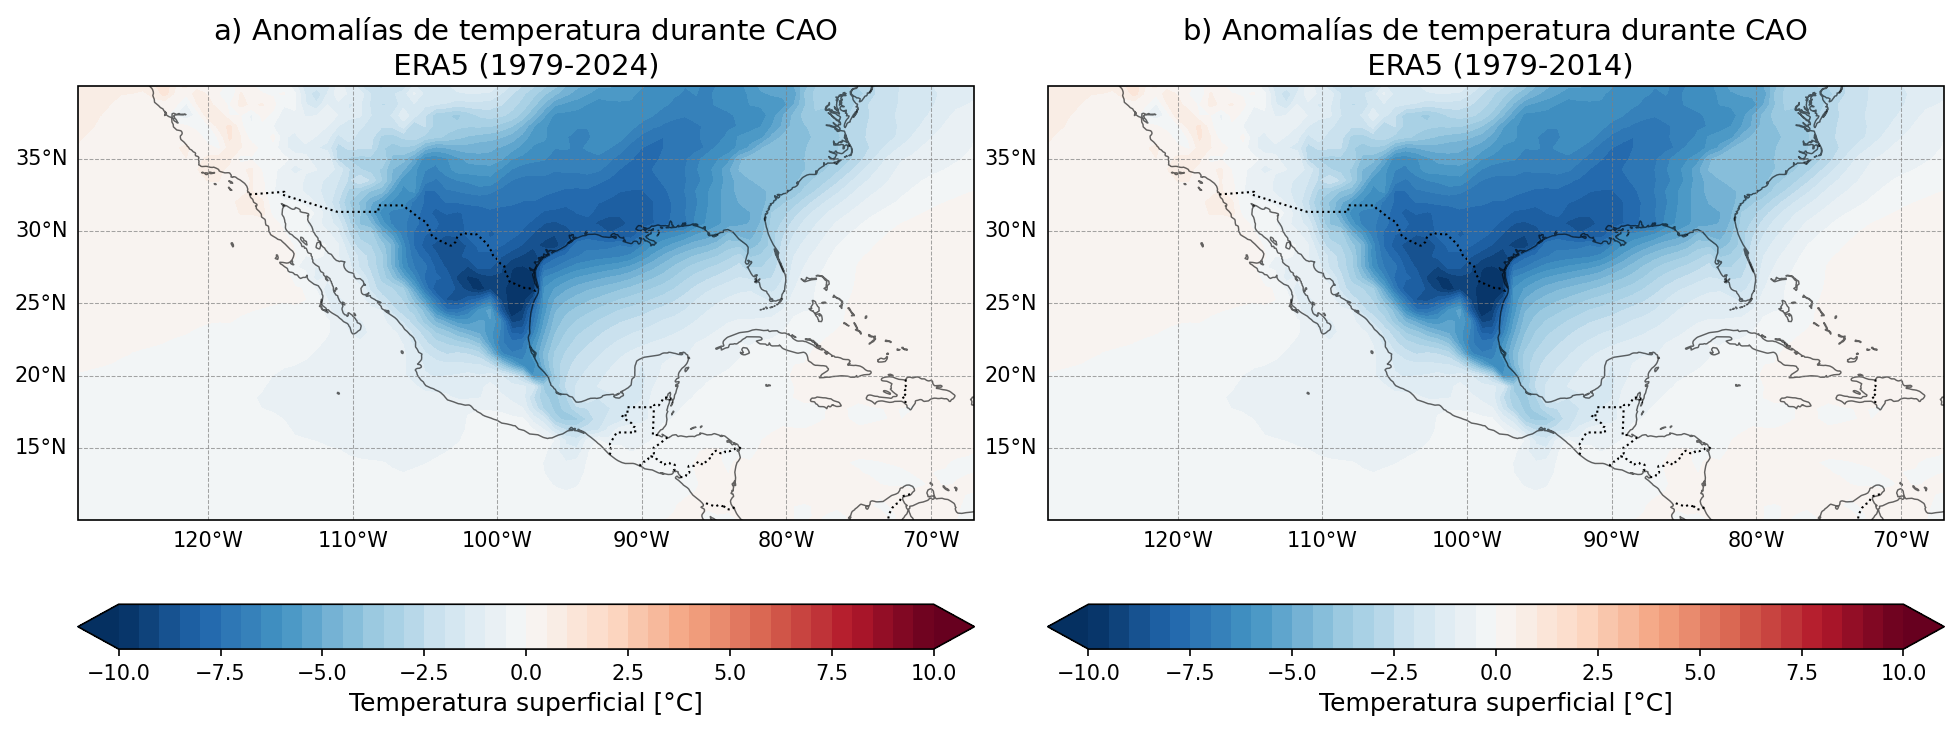

In [36]:
# fig, axs = plt.subplots(1, 2, figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})


# MÉTODO 1: SIN CICLO ANUAL HG ( YA OK ) -------------------------------------------------------------------------------------------
# ax = axs[0]
# ax.coastlines()
# cs = ax.contourf(TanomaliaHG.lon, TanomaliaHG.lat, TanomaliaHG, levels=np.arange(-10, 10.1, 1), cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
# ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1)
# ax.set_extent([231, 293, 10, 40], crs=ccrs.PlateCarree())
# gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
# gl.top_labels = gl.right_labels = False
# plt.minorticks_on()
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.1, ax=ax, pad=0.1)
# cbar.ax.set_xlabel('Temperatura superficial [°C]', fontsize=10)
# ax.set_title('a$)$ Método 2 - HadGEM3', fontsize=12)

# MÉTODO 1: SIN CICLO ANUAL E5 ( YA OK ) -------------------------------------------------------------------------------------------
# ax = axs[1]
# ax.coastlines()
# cs = ax.contourf(TanomaliaE5.longitude, TanomaliaE5.latitude, TanomaliaE5, levels=np.arange(-10, 10.1, 1), cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
# ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1)
# ax.set_extent([231, 293, 10, 40], crs=ccrs.PlateCarree())
# gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
# gl.top_labels = gl.right_labels = False
# plt.minorticks_on()
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.1, ax=ax, pad=0.1)
# cbar.ax.set_xlabel('Temperatura superficial [°C]', fontsize=10)
# ax.set_title('b$)$ Método 2 - ERA5', fontsize=12)

# MÉTODO 2: CICLO ANUAL HG  -------------------------------------------------------------------------------------------
ax1 = axes[1]
ax1.coastlines(linewidth=0.7,alpha=0.6)
cs = ax1.contourf(tempsE5day.longitude, tempsE5day.latitude, tempsE5day, levels=np.arange(-10, 10.1, 0.5), cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
ax1.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1)
ax1.set_extent([231, 293, 10, 40], crs=ccrs.PlateCarree())
gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
gl.top_labels = gl.right_labels = False
plt.minorticks_on()
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.09,pad=0.1, ax=ax1)
cbar.ax.set_xlabel('Temperatura superficial [°C]', fontsize=12)
ax1.set_title('b$)$ Anomalías de temperatura durante CAO \n ERA5 (1979-2014)', fontsize=14)

# MÉTODO 2: CICLO ANUAL E5 -------------------------------------------------------------------------------------------
ax2 = axes[0]
ax2.coastlines(linewidth=0.7,alpha=0.6)
cs = ax2.contourf(tempsE5day.longitude, tempsE5day.latitude, tempsE5day, levels=np.arange(-10, 10.1, 0.5), cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
ax2.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1)
ax2.set_extent([231, 293, 10, 40], crs=ccrs.PlateCarree())
gl = ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
gl.top_labels = gl.right_labels = False
plt.minorticks_on()
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.09,pad=0.1, ax=ax2)
cbar.ax.set_xlabel('Temperatura superficial [°C]', fontsize=12)
ax2.set_title('a$)$ Anomalías de temperatura durante CAO \n ERA5 (1979-2024) ', fontsize=14)

fig.tight_layout(pad=0.5,w_pad=0.5)

plt.savefig('figsok/ROSARIO7_metodosCAO')

----
## **<font color="crimson"> Ya ok </font>**

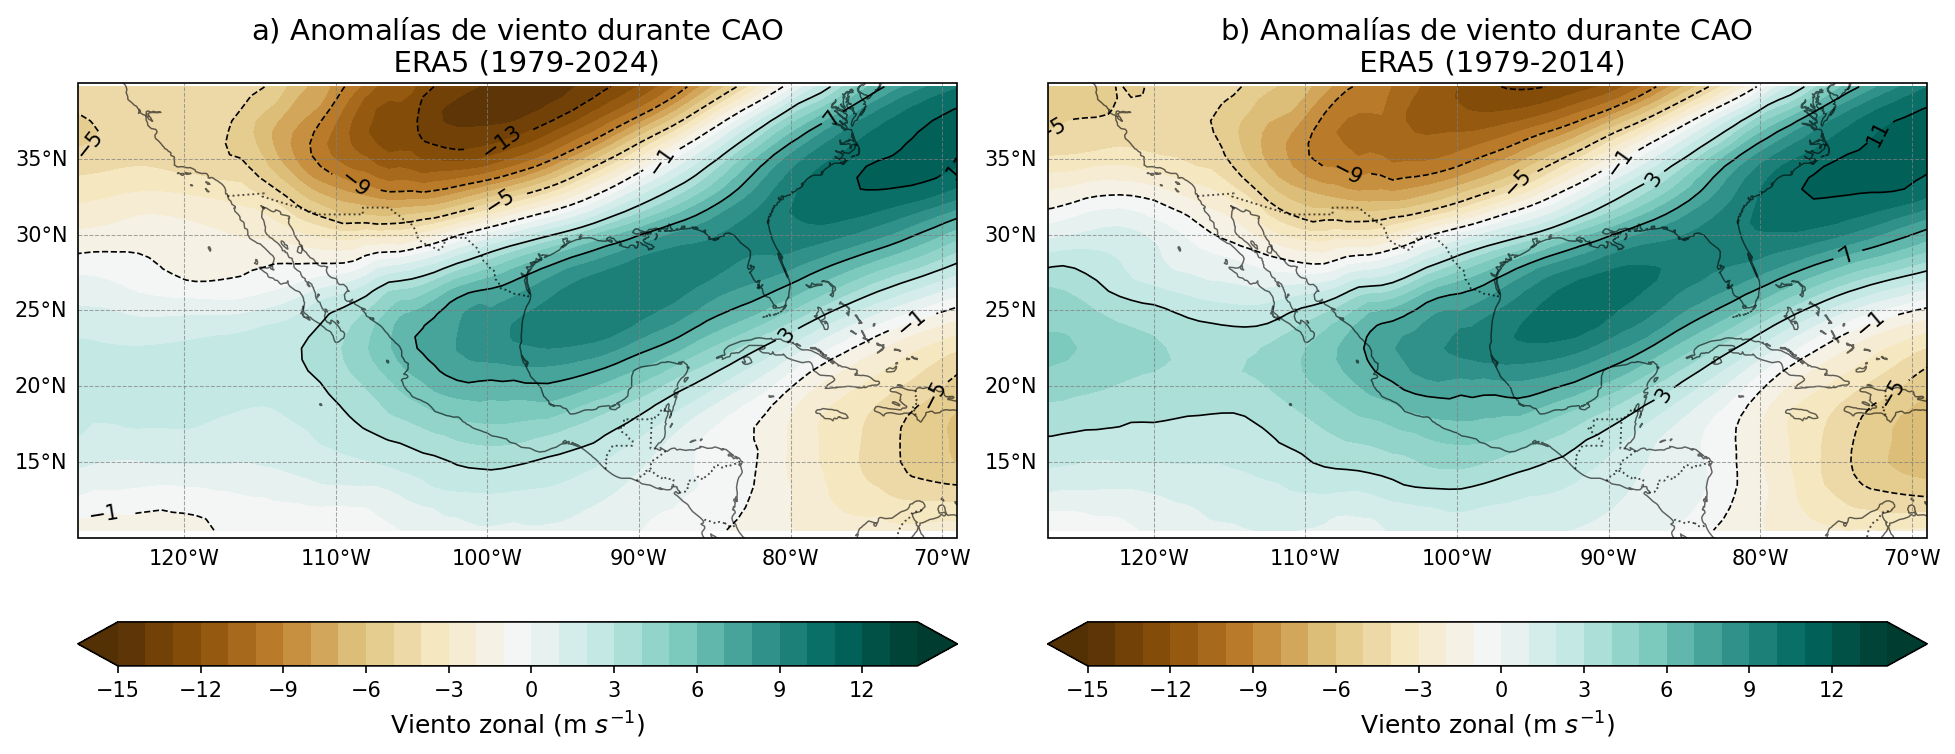

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=150, subplot_kw={'projection': ccrs.PlateCarree()})

# MÉTODO 1: SIN CICLO ANUAL HG ( YA OK ) -------------------------------------------------------------------------------------------
# ax = axs[0]
# ax.coastlines(linewidth=0.7,alpha=0.6)
# cs = ax.contourf(VanomaliaHG.lon, VanomaliaHG.lat, VanomaliaHG, levels=np.arange(-15, 15, 1), cmap='BrBG', extend='both', transform=ccrs.PlateCarree())
# cc=ax.contour(VanomaliaHG.lon, VanomaliaHG.lat, VanomaliaHG, levels=np.arange(-13, 13, 4),colors='k',linewidths=0.8,transform=ccrs.PlateCarree())
# ax.clabel(cc, cc.levels, inline=True, fontsize=10)
# ax.coastlines(linewidth=0.7,alpha=0.6)
# ax.set_extent([233, 291, 10, 40], crs=ccrs.PlateCarree())
# gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
# gl.top_labels = gl.right_labels = False
# plt.minorticks_on()
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.1, ax=ax, pad=0.1)
# cbar.ax.set_xlabel('Viento zonal (m $s^{-1}$)', fontsize=10)
# ax.set_title('a$)$ Método 2 - HadGEM3', fontsize=12)


# MÉTODO 1: SIN CICLO ANUAL E5 ( YA OK ) -------------------------------------------------------------------------------------------
# ax = axs[1]
# ax.coastlines(linewidth=0.7,alpha=0.6)
# cs = ax.contourf(VanomaliaE5.longitude, VanomaliaE5.latitude, VanomaliaE5, levels=np.arange(-15, 15, 1), cmap='BrBG', extend='both', transform=ccrs.PlateCarree())
# cc=ax.contour(VanomaliaE5.longitude, VanomaliaE5.latitude, VanomaliaE5, levels=np.arange(-13, 13, 4),colors='k',linewidths=0.8,transform=ccrs.PlateCarree())
# ax.clabel(cc, cc.levels, inline=True, fontsize=10)
# ax.coastlines(linewidth=0.7,alpha=0.6)
# ax.set_extent([233, 291, 10, 40], crs=ccrs.PlateCarree())
# gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
# gl.top_labels = gl.right_labels = False
# plt.minorticks_on()
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.1, ax=ax, pad=0.1)
# cbar.ax.set_xlabel('Viento zonal (m $s^{-1}$)', fontsize=10)
# ax.set_title('b$)$ Método 2 - ERA5', fontsize=12)

# MÉTODO 2: CICLO ANUAL HG  -------------------------------------------------------------------------------------------
ax1 = axes[1]
ax1.coastlines(linewidth=0.7,alpha=0.6)
cs = ax1.contourf(usE5dayROSARIO.longitude, usE5dayROSARIO.latitude, usE5dayROSARIO, levels=np.arange(-15, 15, 1), cmap='BrBG', extend='both', transform=ccrs.PlateCarree())
cc=ax1.contour(usE5dayROSARIO.longitude, usE5dayROSARIO.latitude, usE5dayROSARIO, levels=np.arange(-13, 13, 4),colors='k',linewidths=0.8,transform=ccrs.PlateCarree())
ax1.clabel(cc, cc.levels, inline=True, fontsize=10)
ax1.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.9,alpha=0.7)
ax1.set_extent([233, 291, 10, 40], crs=ccrs.PlateCarree())
gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
gl.top_labels = gl.right_labels = False
plt.minorticks_on()
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.1, ax=ax1, pad=0.1)
cbar.ax.set_xlabel('Viento zonal (m $s^{-1}$)', fontsize=12)
ax1.set_title('b$)$ Anomalías de viento durante CAO \n ERA5 (1979-2014)', fontsize=14)

# MÉTODO 2: CICLO ANUAL E5 -------------------------------------------------------------------------------------------
ax2 = axes[0]
ax2.coastlines(linewidth=0.7,alpha=0.6)
cs = ax2.contourf(usE5day.longitude, usE5day.latitude, usE5day, levels=np.arange(-15, 15, 1), cmap='BrBG', extend='both', transform=ccrs.PlateCarree())
cc=ax2.contour(usE5day.longitude, usE5day.latitude, usE5day,levels=np.arange(-13, 13, 4),colors='k',linewidths=0.8,transform=ccrs.PlateCarree())
ax2.clabel(cc, cc.levels, inline=True, fontsize=10)
ax2.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.9,alpha=0.7)
ax2.set_extent([233, 291, 10, 40], crs=ccrs.PlateCarree())
gl = ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.7, linestyle='--', linewidth=0.5)
gl.top_labels = gl.right_labels = False
plt.minorticks_on()
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.1, ax=ax2, pad=0.1)
cbar.ax.set_xlabel('Viento zonal (m $s^{-1}$)', fontsize=12)
ax2.set_title('a$)$ Anomalías de viento durante CAO \n  ERA5 (1979-2024)', fontsize=14)

fig.tight_layout(pad=0.5,w_pad=0.5)

plt.savefig('figsok/ROSARIO9_metodosCAOyviento')


----
## **<font color="crimson"> Prueba estadística </font>**

In [39]:
caoshgdf = pd.read_csv('datasetsok/fechasCAOs_HG.csv')

In [44]:
years_hg=2014-1978
years_e5=2024-1978

In [49]:
rateshg=len(caoshgdf)/years_hg

In [50]:
ratese5=len(caosE5df)/years_e5

In [59]:
caosE5dfROSARIO

,fecha,indice
0,1986-01-09,640
1,1979-01-02,1
2,1979-01-03,2
3,1986-01-10,641
4,2002-01-02,2077
5,2002-01-03,2078
6,1997-12-12,1695
7,1985-01-03,544
8,1985-01-04,545
9,1985-01-05,546


In [51]:
rateshg

1.7222222222222223

In [65]:
def rr_from_event_days(df1, df2, years1, years2, alpha=0.05, continuity=0.5,p=5):
    k1 = len(df1)
    k2 = len(df2)

    k1c = k1 + continuity
    k2c = k2 + continuity

    rate1 = k1c / years1
    rate2 = k2c / years2
    RR = rate1 / rate2

    z = {5:1.959963984540054,10:1.6448536269514722}[p]  # 95%

    se = np.sqrt(1.0/k1c + 1.0/k2c)

    ci_low = np.exp(np.log(RR) - z*se)
    ci_high = np.exp(np.log(RR) + z*se)

    return {
        "k1_days": k1, "k2_days": k2,
        "years1": years1, "years2": years2,
        "rate1_days_per_year": rate1, "rate2_days_per_year": rate2,
        "RR": RR, "CI_low": ci_low, "CI_high": ci_high,
        "continuity": continuity
    }



In [56]:
def count_episodes(df, date_col="fecha"):
    """Counts episodes as runs of consecutive days in the event-date list."""
    d = pd.to_datetime(df[date_col]).sort_values().reset_index(drop=True)

    # new episode if gap > 1 day (first day always starts an episode)
    gap_days = d.diff().dt.days
    new_episode = gap_days.isna() | (gap_days > 1)

    return int(new_episode.sum())

def rr_from_episodes(df1, df2, years1, years2, date_col="fecha",
                     continuity=0.5):
    """
    Rate ratio comparing episode rates between two datasets:
    RR = (k1/years1)/(k2/years2), with Wald 95% CI on log scale.
    """
    k1 = count_episodes(df1, date_col=date_col)
    k2 = count_episodes(df2, date_col=date_col)

    # continuity correction (helps if k1 or k2 is 0)
    k1c = k1 + continuity
    k2c = k2 + continuity

    rate1 = k1c / years1
    rate2 = k2c / years2
    RR = rate1 / rate2

    z = 1.959963984540054  # 95% CI
    se = np.sqrt(1.0/k1c + 1.0/k2c)

    ci_low = np.exp(np.log(RR) - z*se)
    ci_high = np.exp(np.log(RR) + z*se)

    return {
        "k1_episodes": k1,
        "k2_episodes": k2,
        "years1": years1,
        "years2": years2,
        "rate1_episodes_per_year": rate1,
        "rate2_episodes_per_year": rate2,
        "RR": RR,
        "CI_low": ci_low,
        "CI_high": ci_high,
        "continuity": continuity
    }


In [72]:
out_dias = rr_from_event_days(caoshgdf, caosE5df, years1=years_hg, years2=years_e5)

# --- Run it ---
out_events = rr_from_episodes(caoshgdf, caosE5df, years1=years_hg, years2=years_e5, date_col="fecha", continuity=0.5)


In [73]:
out_dias

{'k1_days': 62,
 'k2_days': 70,
 'years1': 36,
 'years2': 46,
 'rate1_days_per_year': 1.7361111111111112,
 'rate2_days_per_year': 1.5326086956521738,
 'RR': 1.132781717888101,
 'CI_low': 0.8058633248660155,
 'CI_high': 1.5923226442832148,
 'continuity': 0.5}

In [74]:
out_dias = rr_from_event_days(caoshgdf, caosE5df, years1=years_hg, years2=years_e5,p=10)

# --- Run it ---
out_events = rr_from_episodes(caoshgdf, caosE5df, years1=years_hg, years2=years_e5, date_col="fecha", continuity=0.5)

In [75]:
out_dias

{'k1_days': 62,
 'k2_days': 70,
 'years1': 36,
 'years2': 46,
 'rate1_days_per_year': 1.7361111111111112,
 'rate2_days_per_year': 1.5326086956521738,
 'RR': 1.132781717888101,
 'CI_low': 0.8512112626330759,
 'CI_high': 1.5074922956401864,
 'continuity': 0.5}

In [60]:

out_dias = rr_from_event_days(caoshgdf, caosE5dfROSARIO, years1=years_hg, years2=years_hg)

# --- Run it ---
out_events = rr_from_episodes(caoshgdf, caosE5dfROSARIO, years1=years_hg, years2=years_hg, date_col="fecha", continuity=0.5)

In [62]:
out_dias

{'k1_days': 62,
 'k2_days': 56,
 'years1': 36,
 'years2': 36,
 'rate1_days_per_year': 1.7361111111111112,
 'rate2_days_per_year': 1.5694444444444444,
 'RR': 1.1061946902654867,
 'CI_low': 0.7719226588816643,
 'CI_high': 1.5852192945655503,
 'continuity': 0.5}